In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pygmt

# Example useage of SN-CAST

## Model Setup 

First we need to define the configuration paramters of the model. These are the Region we want to model and also the method we want to use.
Here we will use the default method, which is to use the Local Magnitude Scale calibrated for California. 

In [2]:
from sncast.core import ModelConfig

In [3]:
ExampleConfig = ModelConfig(method='ML', region='UK', snr=3.0, foc_depth_km=2, nproc=2)
ExampleConfig

<ModelConfig with method=ML, region=UK, snr=3.0>

Now initialise the DetectionCapabilityModel

In [4]:
from sncast.model_detection_capability import DetectionCapabilityModel

In [5]:
ExampleModel = DetectionCapabilityModel(config=ExampleConfig)


Detection Capability Model initialized.


Now define the model geographical extent and initialise the grid 

In [6]:
ExampleModel.setup_grid(lon0=-2, lon1=3, lat0=49, lat1=56, dlon=0.1, dlat=0.1)


Now add data for the UK seismic network - noise levels must be precomputed!

In [7]:
ExampleModel.add_network("data/GB_network_Nov24_noise_estimate.csv", network_code="GB")

Seismic network GB created and added to model.


In [8]:
ExampleConfig.add_grid_params(lon0=-2., lon1=3., lat0=49, lat1=56, dlon=0.1, dlat=0.1)

In [20]:
uk_base_model = ExampleModel.run_model(return_result=True)

No seismic arrays provided to model.
No DAS fibres provided to model.
Grid created with 51 x 71 points.
Using 1 cores


In [23]:
uk_base_model

<xarray.DataArray (Latitude: 71, Longitude: 51)> Size: 29kB
array([[0.9, 0.9, 1. , ..., 1.8, 1.8, 1.8],
       [0.8, 0.9, 1. , ..., 1.8, 1.8, 1.8],
       [0.9, 0.9, 0.9, ..., 1.8, 1.8, 1.8],
       ...,
       [1.5, 1.5, 1.5, ..., 2.1, 2.1, 2.1],
       [1.5, 1.5, 1.5, ..., 2.1, 2.1, 2.1],
       [1.6, 1.6, 1.6, ..., 2.1, 2.1, 2.2]])
Coordinates:
  * Latitude   (Latitude) float64 568B 56.0 55.9 55.8 55.7 ... 49.2 49.1 49.0
  * Longitude  (Longitude) float64 408B -2.0 -1.9 -1.8 -1.7 ... 2.7 2.8 2.9 3.0

## Plot Example Model

In [21]:
region = [ExampleModel.config.lon0, ExampleModel.config.lon1, ExampleModel.config.lat0, ExampleModel.config.lat1]

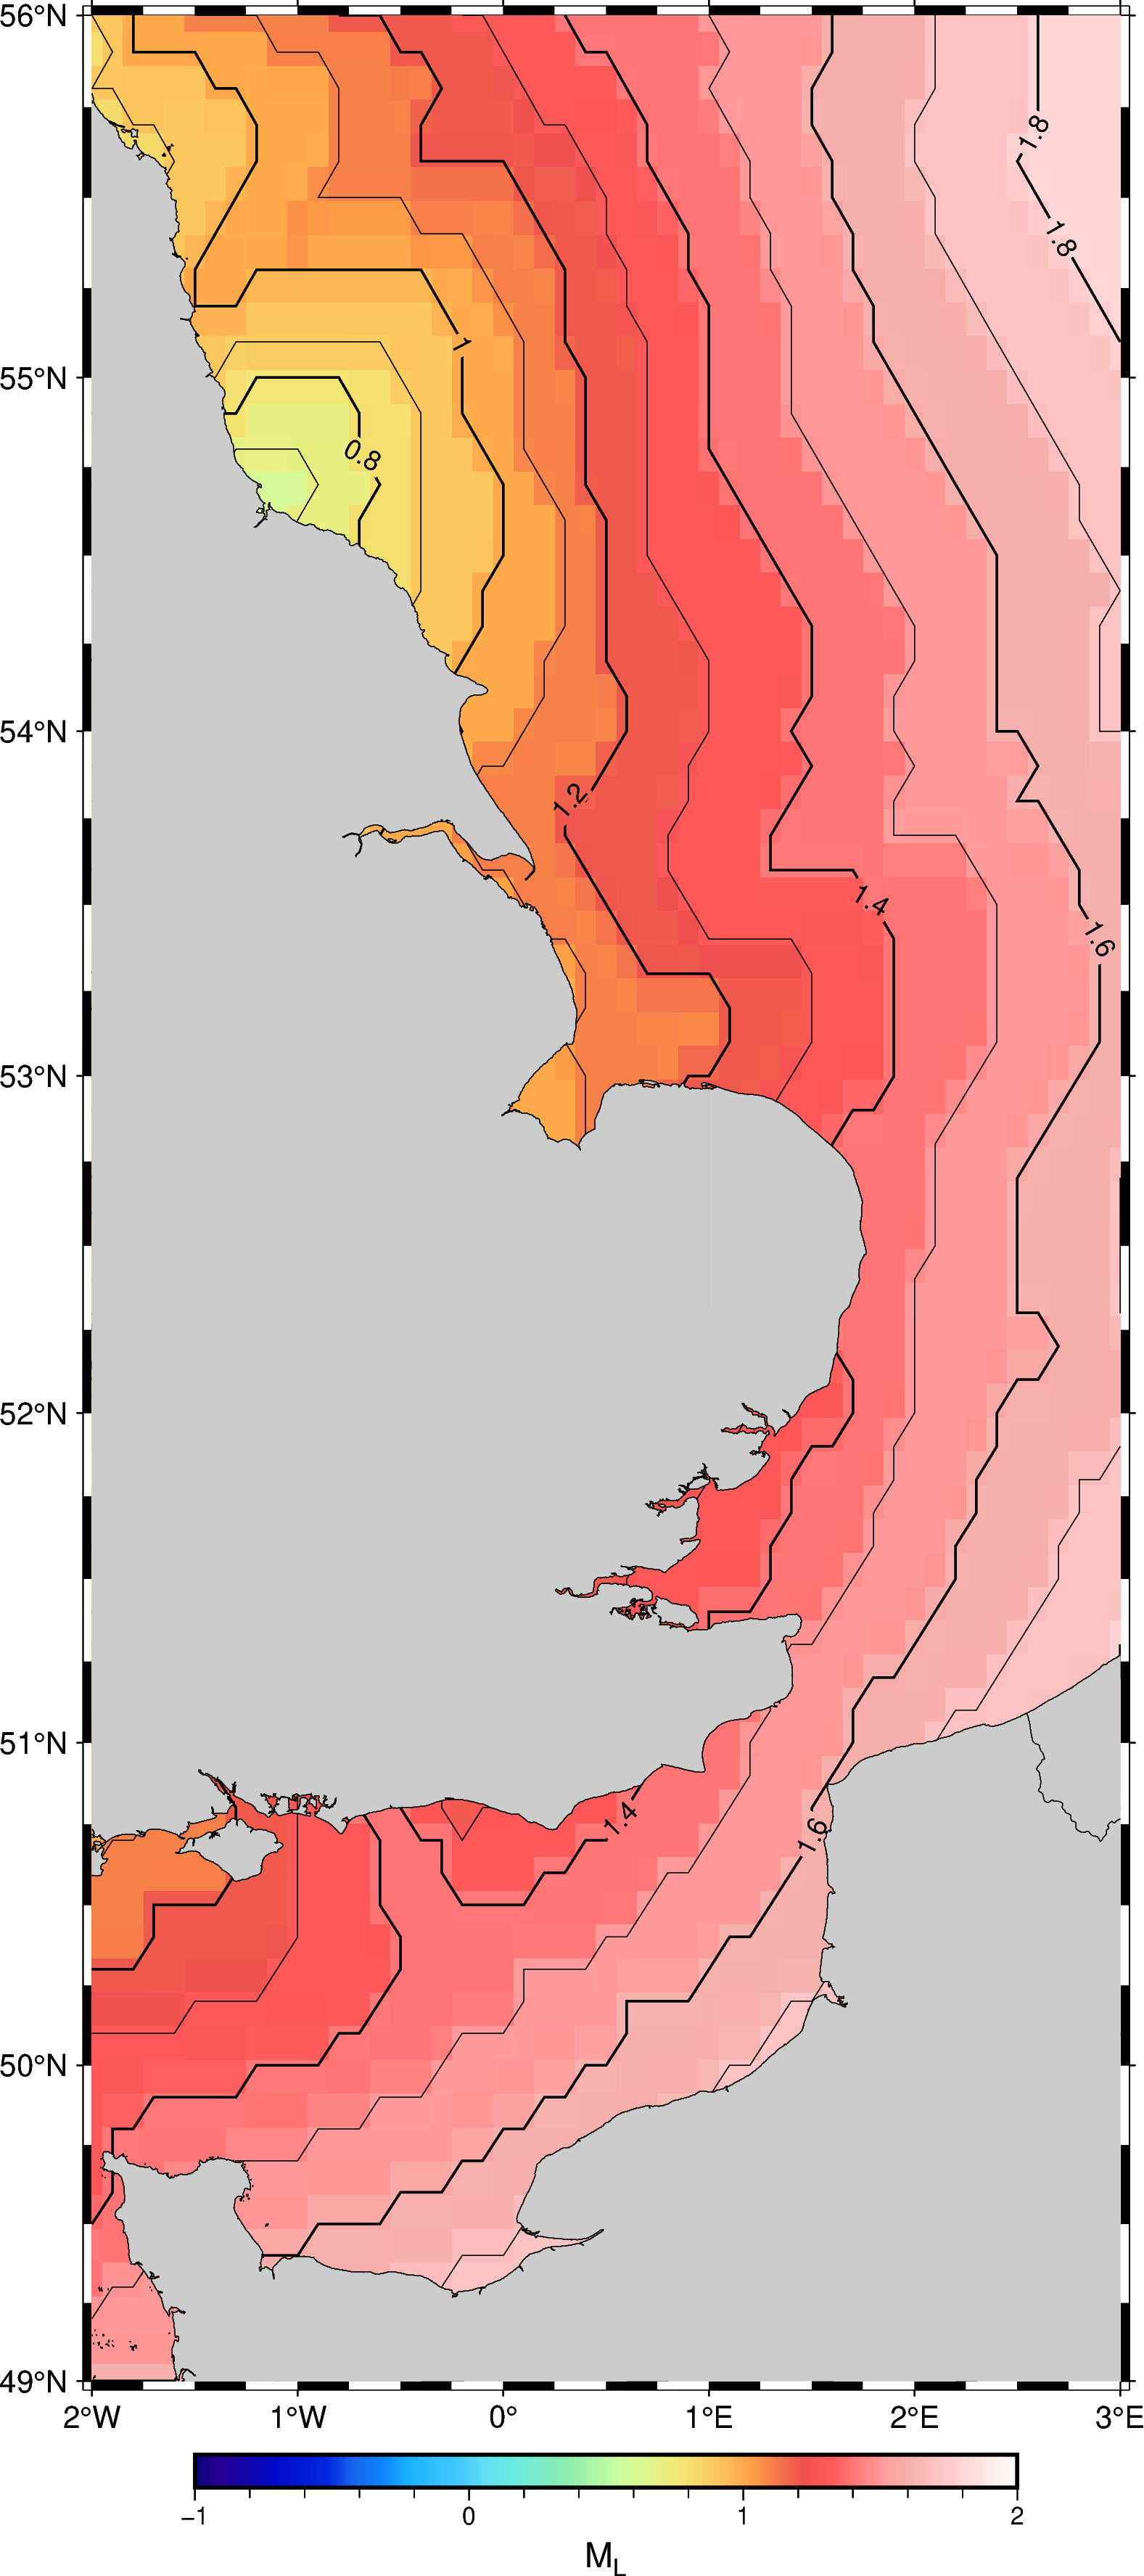

In [22]:
figure = pygmt.Figure()
figure.basemap(projection='M12c',
               region=region,
               frame=["af"])

pygmt.makecpt(cmap='haxby', series=[-1, 2])
figure.grdimage(grid=uk_base_model)
figure.grdcontour(grid=uk_base_model,
                  levels=0.1, annotation=0.2,
                  label_placement='n2')
figure.colorbar(frame=['x+lM@-L@-'])
figure.coast(shorelines=True,
             land='grey80',
             borders='1',
             rivers=0)

figure.show()

In [16]:
uk_base_model